# 03 — Threshold Analysis

Analysis notebook for the three-city heat threshold comparison.
No GEE calls, no heavy computation — loads cached data only.

**Prerequisites:** run `01_data_acquisition` then `02_compute_baselines` first.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city,
    load_baseline,
    threshold_sensitivity_curve,
    compute_absolute_heat_days,
    compute_relative_heat_days,
    load_neighbourhood_boundaries,
    aggregate_to_neighbourhoods,
    plot_sensitivity_curves,
    plot_comparison_maps,
    plot_quadrant,
)

In [2]:
# Analysis parameters — edit here, not inside functions
DATA_DIR        = 'data'
YEAR            = 2020          # representative year for spatial maps
PERCENTILE      = 90            # relative-threshold percentile for maps and quadrant
ABS_THRESHOLD   = 30.0          # absolute Tmax threshold in degrees C
THRESHOLD_RANGE = range(20, 41) # sweep for sensitivity curves
CITY_KEYS       = ['salvador', 'teresina', 'caceres']

# Load all Tmax DataArrays (fast — local disk only)
cities = {c: load_city(c, DATA_DIR) for c in CITY_KEYS}

# Load pre-computed per-pixel baselines
baselines = {c: load_baseline(c, DATA_DIR) for c in CITY_KEYS}

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 55, 'lon': 67}
teresina baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 67, 'lon': 78}
caceres baseline: percentiles [50, 75, 90, 95, 99], shape {'percentile': 5, 'lat': 89, 'lon': 89}


## Threshold sensitivity

How many heat days per year does each city accumulate as we raise the
absolute Tmax threshold from 20 °C to 40 °C?  The left panel shows the
three-city overlay.  The right panel maps each percentile level to the
corresponding spatial-mean temperature so you can read off what 30 °C
means in relative terms for each city.

In [3]:
# Compute sensitivity curves for all cities
curves = {
    CITIES[c]['label']: threshold_sensitivity_curve(cities[c], THRESHOLD_RANGE)
    for c in CITY_KEYS
}

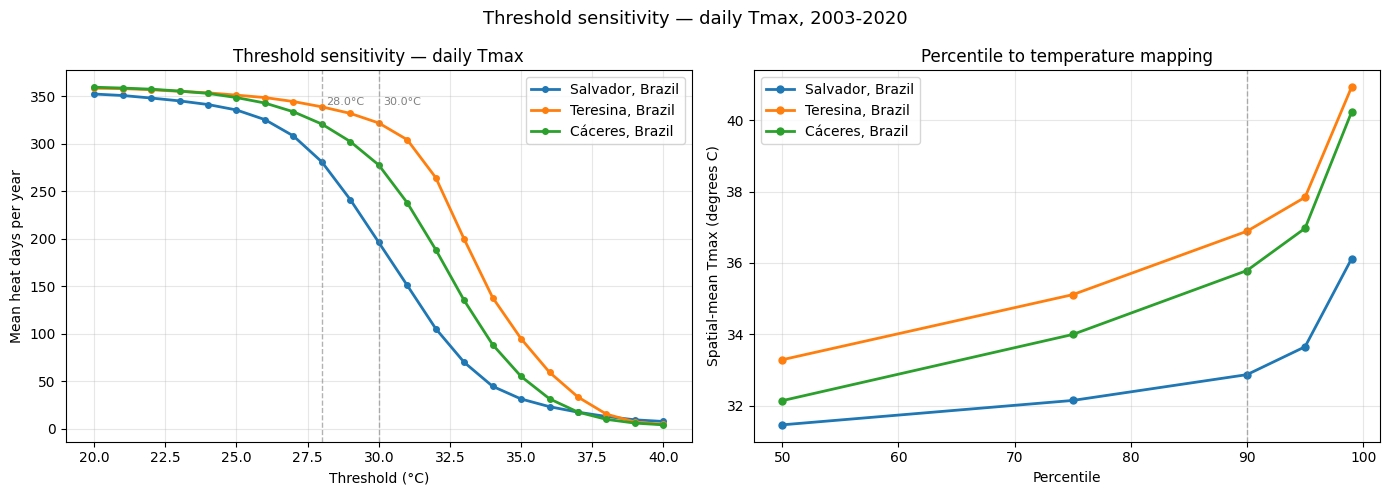

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heat days per year vs threshold
plot_sensitivity_curves(
    curves, ax=axes[0],
    highlight_thresholds=[ABS_THRESHOLD, ABS_THRESHOLD - 2],
)

# Right: percentile -> spatial-mean temperature for each city
pct_labels = [50, 75, 90, 95, 99]
for c in CITY_KEYS:
    vals = [float(baselines[c].sel(percentile=p).mean()) for p in pct_labels]
    axes[1].plot(pct_labels, vals, marker='o', linewidth=2,
                 markersize=5, label=CITIES[c]['label'])

axes[1].axvline(PERCENTILE, color='grey', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Spatial-mean Tmax (degrees C)')
axes[1].set_title('Percentile to temperature mapping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Threshold sensitivity — daily Tmax, 2003-2020', fontsize=13)
plt.tight_layout()
plt.show()

## Spatial patterns

Side-by-side choropleth maps for each city showing neighbourhood-level mean
heat days under two threshold framings:

- **Absolute:** days where Tmax >= 30 °C (cross-city comparable)
- **Relative:** days where Tmax exceeds each pixel's own 90th-percentile
  baseline (locally calibrated)

Neighbourhood boundaries are loaded from geobr (2010 census) and cached
locally after the first download.

### Salvador

Cached to data/geobr_salvador_neighbourhoods_2010.gpkg


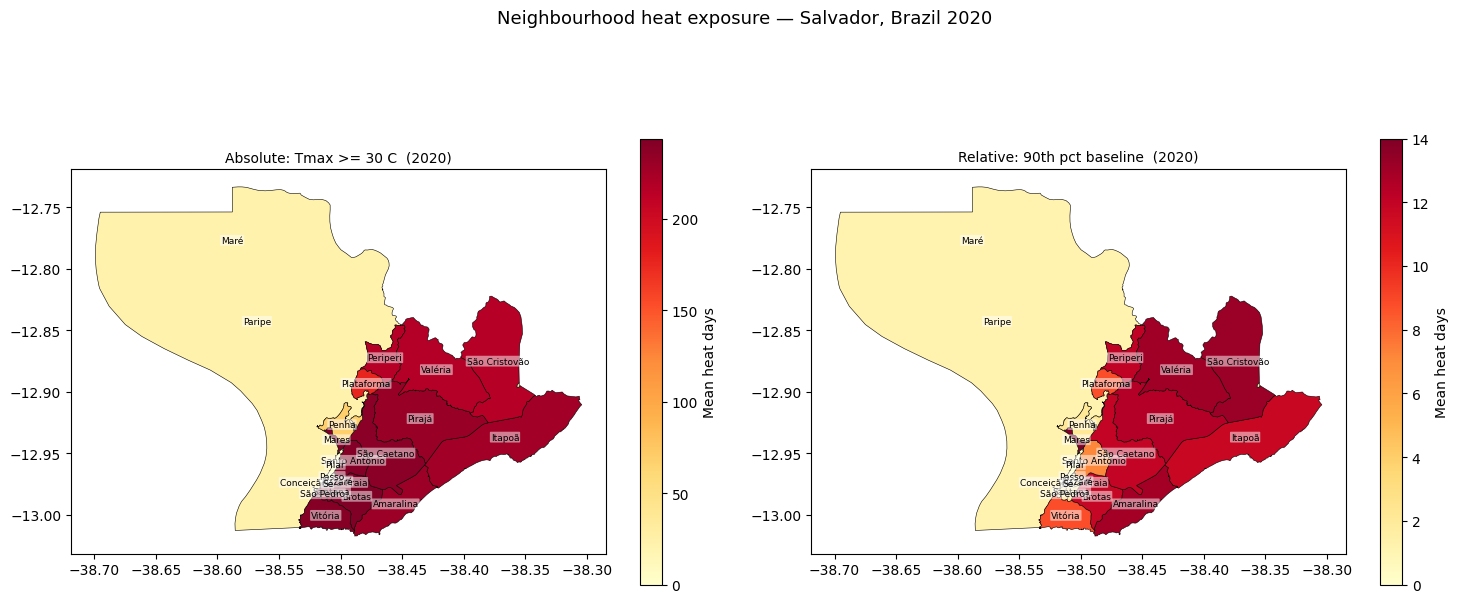

In [5]:
gdf_sal = load_neighbourhood_boundaries('salvador', DATA_DIR)
abs_sal, rel_sal = plot_comparison_maps(
    cities['salvador'], gdf_sal, YEAR, PERCENTILE,
    baselines['salvador'], ABS_THRESHOLD, CITIES['salvador']['label'],
)

### Teresina

Cached to data/geobr_teresina_neighbourhoods_2010.gpkg


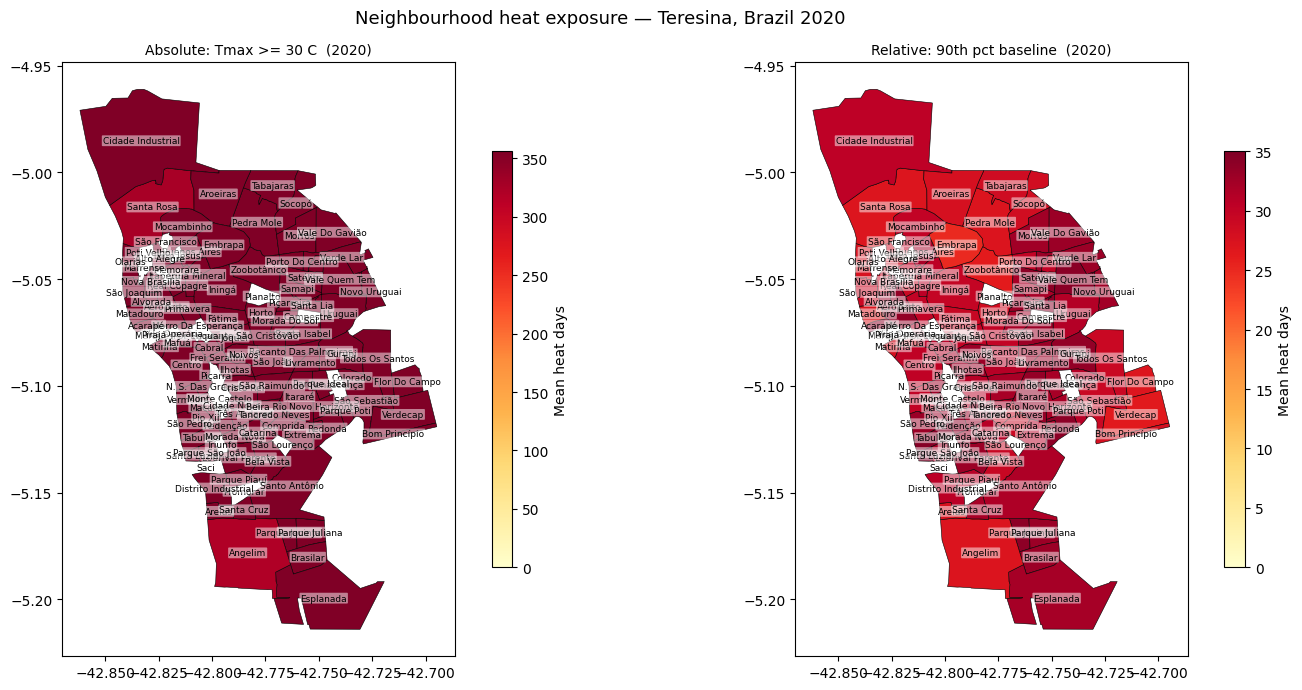

In [6]:
gdf_ter = load_neighbourhood_boundaries('teresina', DATA_DIR)
abs_ter, rel_ter = plot_comparison_maps(
    cities['teresina'], gdf_ter, YEAR, PERCENTILE,
    baselines['teresina'], ABS_THRESHOLD, CITIES['teresina']['label'],
)

### Caceres

Cached to data/geobr_caceres_neighbourhoods_2010.gpkg


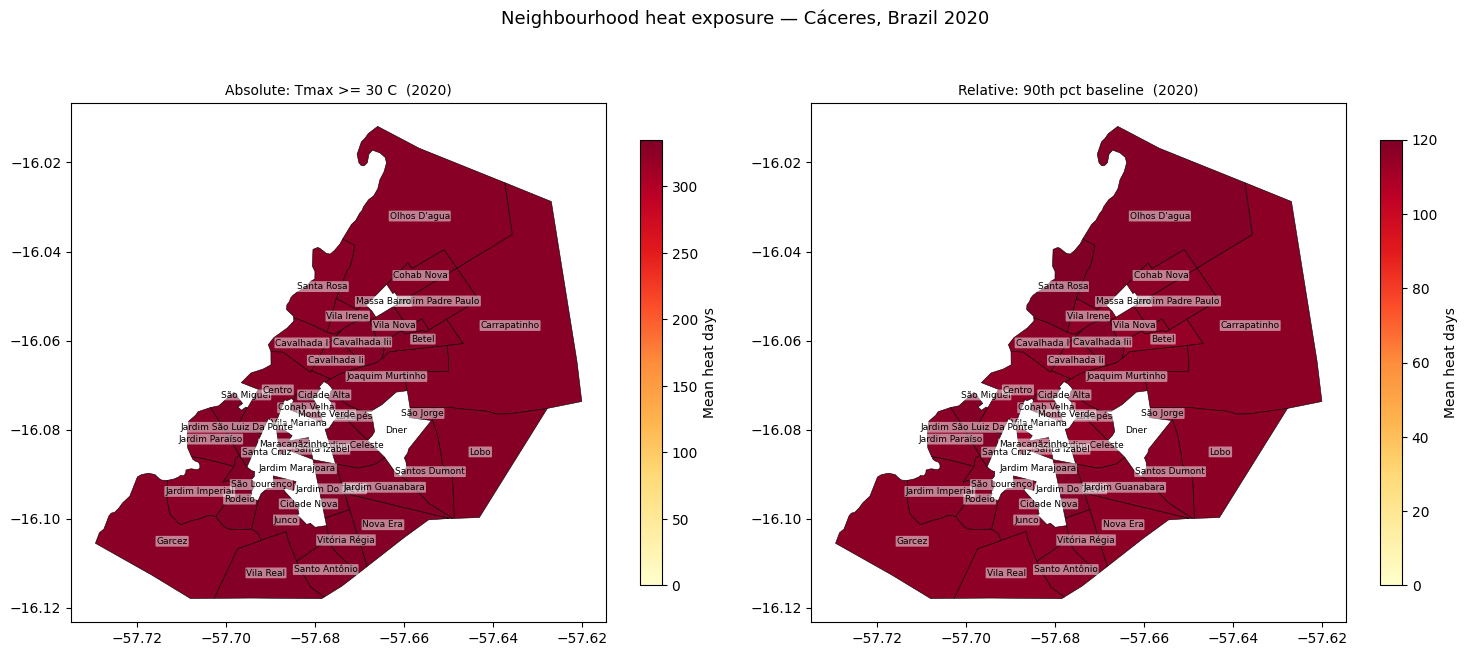

In [7]:
gdf_cac = load_neighbourhood_boundaries('caceres', DATA_DIR)
abs_cac, rel_cac = plot_comparison_maps(
    cities['caceres'], gdf_cac, YEAR, PERCENTILE,
    baselines['caceres'], ABS_THRESHOLD, CITIES['caceres']['label'],
)

## Neighbourhood prioritisation

Rank each neighbourhood simultaneously on both framings.  Neighbourhoods in
the top-right quadrant (high absolute rank **and** high relative rank) are
robust priorities — they show up as high-burden regardless of which threshold
method is applied.

Spearman rho quantifies agreement between the two rankings; rho near 1 means
the choice of framing barely matters for prioritisation.

### Salvador

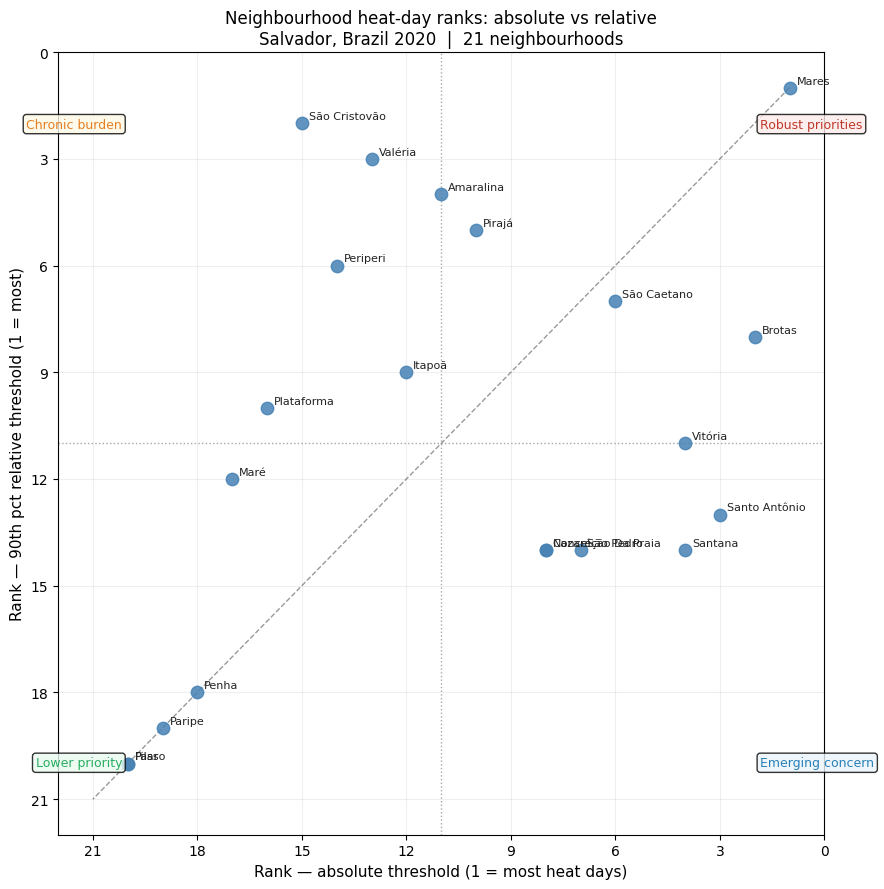

Spearman rho = 0.382  (p = 0.088,  n = 21)


In [8]:
plot_quadrant(abs_sal, rel_sal, YEAR, PERCENTILE, CITIES['salvador']['label'])

### Teresina

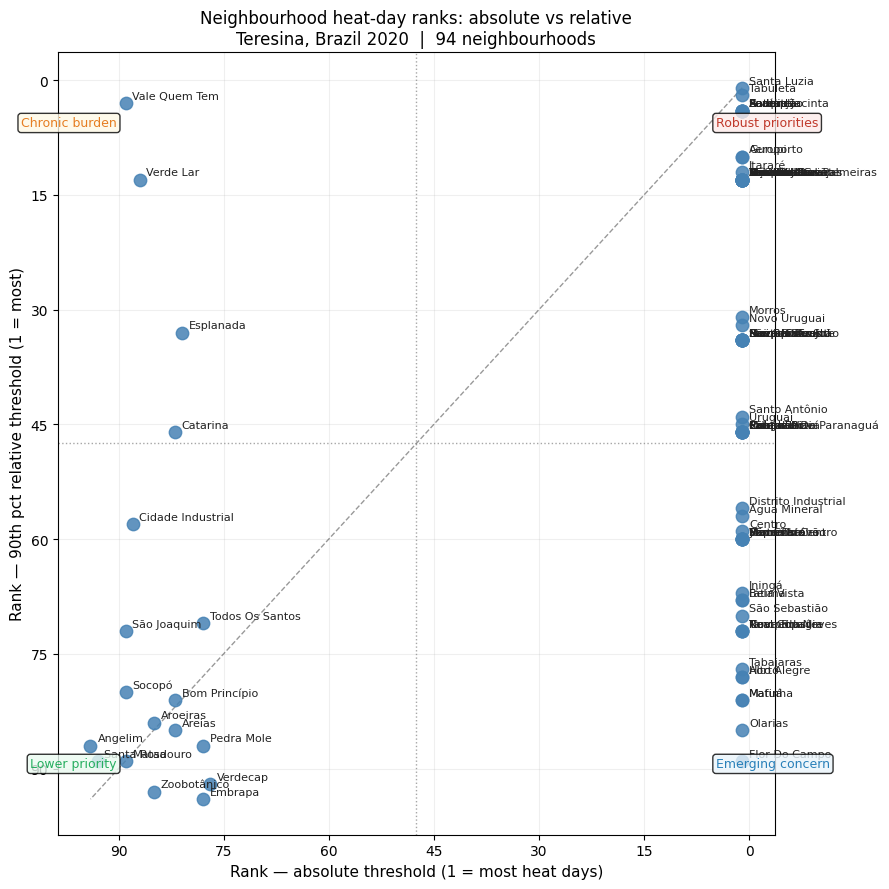

Spearman rho = 0.413  (p = <0.001,  n = 94)


In [9]:
plot_quadrant(abs_ter, rel_ter, YEAR, PERCENTILE, CITIES['teresina']['label'])

### Caceres

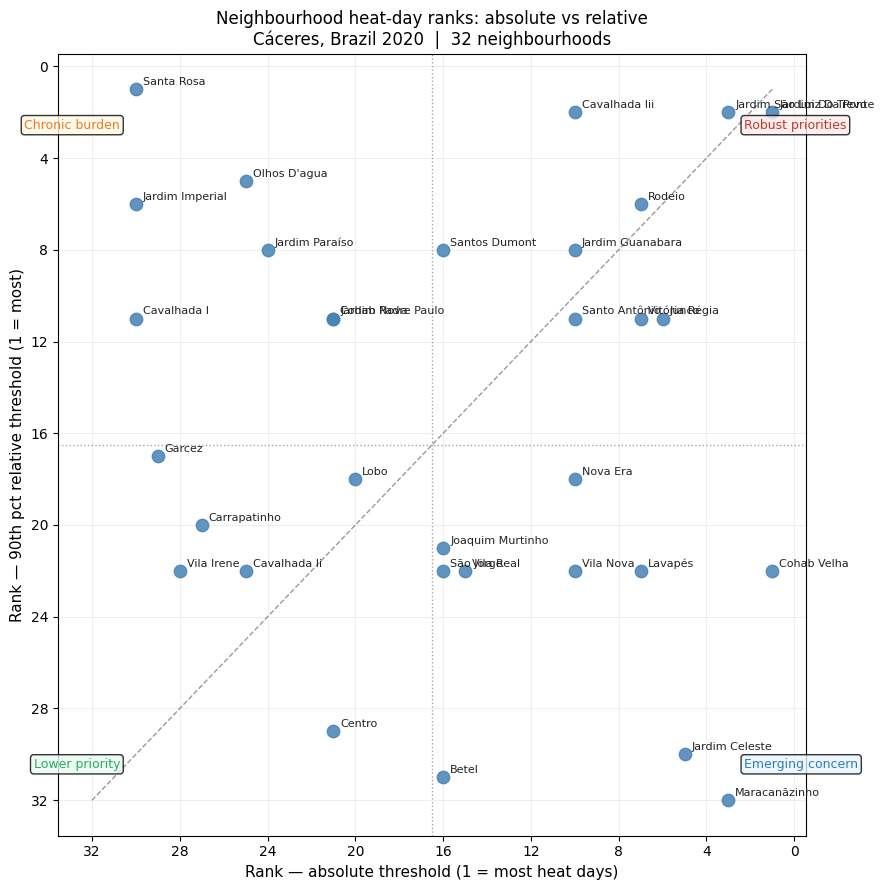

Spearman rho = -0.105  (p = 0.569,  n = 32)


In [10]:
plot_quadrant(abs_cac, rel_cac, YEAR, PERCENTILE, CITIES['caceres']['label'])

## Summary

Key outputs from this notebook:

1. **Sensitivity curves** — show the steep trade-off between threshold level and
   heat day count, and how the three cities compare at any given threshold.

2. **Percentile-to-temperature mapping** — anchors the abstract percentile labels
   to real temperatures, making the relative threshold interpretable.

3. **Spatial maps** — reveal within-city heterogeneity; absolute and relative
   framings can highlight different neighbourhoods.

4. **Quadrant plots** — identify neighbourhoods that are robustly high-burden
   under both framings, informing prioritisation decisions.

To change the analysis year or threshold, edit the parameters in the Setup
section and re-run from that cell.